# Step 2f: Put Option Pricing via Monte Carlo (Bates Model)
**Sub-group 2 | Members 4-6**

---

## 1. Monte Carlo Simulation under the Bates (1996) Model

To price the 70-day put option with 95% moneyness, we will simulate the paths of the underlying stock $S_t$ and its variance $v_t$ using the **Euler-Maruyama discretization scheme**. 

Because we are in Step 2, we use the Bates jump-diffusion dynamics calibrated to the 60-day market data. Under the risk-neutral measure, the discretized equations for a small time step $\Delta t$ are:

### 1.1 Variance Process (CIR)
Using the full truncation scheme to prevent negative variance:
$$v_{t+\Delta t} = v_t + \kappa(\theta - v_t^+)\Delta t + \sigma \sqrt{v_t^+ \Delta t} Z_2$$
Where $v_t^+ = \max(v_t, 0)$ and $Z_2 \sim \mathcal{N}(0,1)$.

### 1.2 Stock Price Process (with Jumps)
$$\ln S_{t+\Delta t} = \ln S_t + \left(r - \lambda \bar{k} - \frac{1}{2}v_t^+\right)\Delta t + \sqrt{v_t^+ \Delta t} Z_1 + J \Delta N$$
Where:
* $Z_1$ is a standard normal variable correlated with $Z_2$ by $\rho$.
* $\Delta N \sim \text{Poisson}(\lambda \Delta t)$ is the number of jumps in the interval.
* $J \sim \mathcal{N}(\mu_J, \sigma_J^2)$ is the log-jump size.
* $\bar{k} = \exp(\mu_J + \frac{1}{2}\sigma_J^2) - 1$ is the jump compensator to maintain the risk-neutral martingale property.

### 1.3 Pricing & Bank Fee
The fair value of the European put option is the discounted expected payoff:
$$P_{fair} = e^{-rT} \mathbb{E}[\max(K - S_T, 0)]$$
The final price quoted to the client includes the bank's 4% margin:
$$P_{client} = P_{fair} \times 1.04$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ─────────────────────────────────────────────────────────────
# 0. CONSTANTS & INSTRUMENT DETAILS
# ─────────────────────────────────────────────────────────────
S0          = 232.90        # Current stock price
r           = 0.015         # Risk-free rate
DAYS_YEAR   = 250
TARGET_DAYS = 70            # 70-day maturity
T           = TARGET_DAYS / DAYS_YEAR

# 95% Moneyness Strike
K = 0.95 * S0

# ─────────────────────────────────────────────────────────────
# 1. BATES CALIBRATED PARAMETERS (From Step 2e)
# ─────────────────────────────────────────────────────────────
kappa   = 0.100000
theta   = 0.010000
sigma   = 2.000000
rho     = -0.990000
v0      = 0.010000
lam     = 1.911346      # Jumps per year
mu_j    = 0.208765
sigma_j = 0.010000

print(f"--- Instrument Details ---")
print(f"Spot Price (S0) : ${S0:.2f}")
print(f"Strike (K)      : ${K:.2f} (95% Moneyness)")
print(f"Maturity (T)    : {TARGET_DAYS} days ({T:.4f} years)")
print(f"Risk-free rate  : {r*100:.2f}%")

--- Instrument Details ---
Spot Price (S0) : $232.90
Strike (K)      : $221.25 (95% Moneyness)
Maturity (T)    : 70 days (0.2800 years)
Risk-free rate  : 1.50%


In [3]:
# ─────────────────────────────────────────────────────────────
# 2. MONTE CARLO SIMULATION (BATES MODEL)
# ─────────────────────────────────────────────────────────────
np.random.seed(42)  # For reproducibility

# Simulation Parameters
M = 100_000         # Number of Monte Carlo paths
N = TARGET_DAYS     # Number of time steps (daily)
dt = T / N

# Pre-compute constants
k_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0

# Initialize arrays
S = np.zeros((M, N + 1))
v = np.zeros((M, N + 1))
S[:, 0] = S0
v[:, 0] = v0

print(f"Simulating {M:,} paths over {N} time steps...")

for t in range(1, N + 1):
    # 1. Generate correlated Brownian motions
    Z1 = np.random.standard_normal(M)
    Z2 = np.random.standard_normal(M)
    W1 = Z1
    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
    
    # 2. Generate Jumps
    # Number of jumps in dt (Poisson)
    dN = np.random.poisson(lam * dt, M)
    
    # Jump size (Normal). If dN=0, jump size is 0.
    # For multiple jumps (dN > 1), we sum the normals. 
    # Variance scales by dN.
    jump_sizes = np.where(
        dN > 0, 
        dN * mu_j + np.sqrt(dN) * sigma_j * np.random.standard_normal(M), 
        0.0
    )
    
    # 3. Discretization (Full Truncation Scheme)
    v_prev = np.maximum(v[:, t-1], 0)  # v^+
    
    # Variance process
    v[:, t] = v[:, t-1] + kappa * (theta - v_prev) * dt + sigma * np.sqrt(v_prev * dt) * W2
    
    # Stock process (log-Euler)
    log_S_next = (np.log(S[:, t-1]) 
                  + (r - lam * k_bar - 0.5 * v_prev) * dt 
                  + np.sqrt(v_prev * dt) * W1 
                  + jump_sizes)
    
    S[:, t] = np.exp(log_S_next)

print("Simulation complete.")

Simulating 100,000 paths over 70 time steps...
Simulation complete.


In [4]:
# ─────────────────────────────────────────────────────────────
# 3. PUT OPTION PRICING & BANK FEE
# ─────────────────────────────────────────────────────────────
# Calculate European Put Payoff at maturity (T)
payoffs = np.maximum(K - S[:, -1], 0)

# Discount back to present value
discount_factor = np.exp(-r * T)
discounted_payoffs = discount_factor * payoffs

# Calculate Fair Value (Mean of discounted payoffs)
fair_value = np.mean(discounted_payoffs)

# Calculate Standard Error and 95% Confidence Interval
std_err = np.std(discounted_payoffs) / np.sqrt(M)
ci_lower = fair_value - 1.96 * std_err
ci_upper = fair_value + 1.96 * std_err

# Apply 4% Bank Fee for the final client price
bank_fee_pct = 0.04
client_price = fair_value * (1 + bank_fee_pct)

print("\n" + "="*50)
print("  MONTE CARLO PRICING RESULTS (BATES MODEL)")
print("="*50)
print(f"  Fair Value (Put) : ${fair_value:.4f}")
print(f"  95% Conf. Int.   : [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"  Standard Error   : ${std_err:.4f}")
print("-" * 50)
print(f"  Bank Fee (4%)    : ${fair_value * bank_fee_pct:.4f}")
print(f"  FINAL CLIENT PRICE: ${client_price:.4f}")
print("="*50)


  MONTE CARLO PRICING RESULTS (BATES MODEL)
  Fair Value (Put) : $8.8947
  95% Conf. Int.   : [$8.8199, $8.9695]
  Standard Error   : $0.0381
--------------------------------------------------
  Bank Fee (4%)    : $0.3558
  FINAL CLIENT PRICE: $9.2505


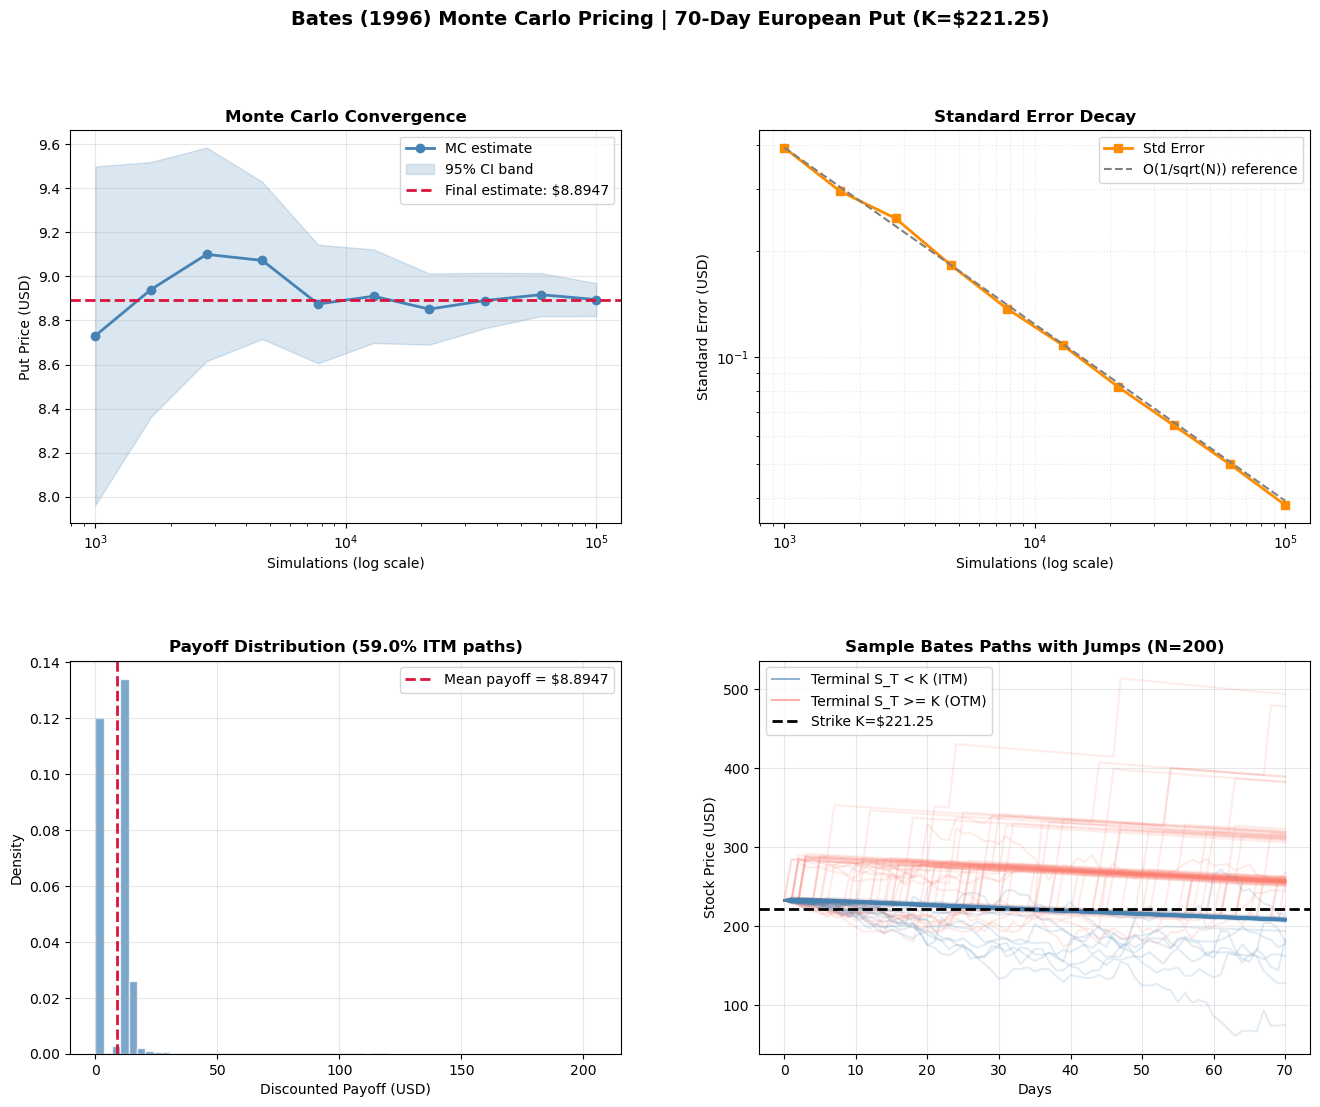

In [7]:
# ─────────────────────────────────────────────────────────────
# 4. COMPREHENSIVE VISUALIZATIONS (BATES MONTE CARLO)
# ─────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

# 1. Prepare data for convergence and standard error plots
# We evaluate the mean and std_error at specific log-spaced checkpoints
checkpoints = np.logspace(3, np.log10(M), num=10).astype(int)
mc_means = [np.mean(discounted_payoffs[:k]) for k in checkpoints]
mc_stderrs = [np.std(discounted_payoffs[:k], ddof=1) / np.sqrt(k) for k in checkpoints]

# Calculate confidence intervals for the convergence plot
ci_upper_band = np.array(mc_means) + 1.96 * np.array(mc_stderrs)
ci_lower_band = np.array(mc_means) - 1.96 * np.array(mc_stderrs)

# Reference line for O(1/sqrt(N)) decay
ref_decay = mc_stderrs[0] * np.sqrt(checkpoints[0]) / np.sqrt(checkpoints)

# 2. Setup the 2x2 Figure
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.25)

# ── Panel A: MC Convergence ──────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(checkpoints, mc_means, 'o-', color='steelblue', lw=2, label='MC estimate')
ax0.fill_between(checkpoints, ci_lower_band, ci_upper_band, color='steelblue', alpha=0.2, label='95% CI band')
ax0.axhline(fair_value, color='crimson', linestyle='--', lw=2, label=f'Final estimate: ${fair_value:.4f}')
ax0.set_xscale('log')
ax0.set_title('Monte Carlo Convergence', fontweight='bold', fontsize=12)
ax0.set_xlabel('Simulations (log scale)')
ax0.set_ylabel('Put Price (USD)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# ── Panel B: Standard Error Decay ────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(checkpoints, mc_stderrs, 's-', color='darkorange', lw=2, label='Std Error')
ax1.plot(checkpoints, ref_decay, '--', color='grey', lw=1.5, label='O(1/sqrt(N)) reference')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Standard Error Decay', fontweight='bold', fontsize=12)
ax1.set_xlabel('Simulations (log scale)')
ax1.set_ylabel('Standard Error (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3, which="both", ls=":")

# ── Panel C: Payoff Distribution ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
itm_pct = np.mean(discounted_payoffs > 0) * 100
ax2.hist(discounted_payoffs, bins=60, color='steelblue', alpha=0.7, edgecolor='white', density=True)
ax2.axvline(fair_value, color='crimson', linestyle='--', lw=2, label=f'Mean payoff = ${fair_value:.4f}')
ax2.set_title(f'Payoff Distribution ({itm_pct:.1f}% ITM paths)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Discounted Payoff (USD)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Panel D: Sample Bates Paths (N=200) ──────────────────────
ax3 = fig.add_subplot(gs[1, 1])
n_plot = 200
time_axis = np.linspace(0, TARGET_DAYS, N + 1)

# Color paths based on Put moneyness (Terminal price < Strike)
terminal_prices = S[:n_plot, -1]
itm_mask = terminal_prices < K  # Put is ITM when S_T < K
otm_mask = ~itm_mask

# Plot OTM paths (red)
if np.any(otm_mask):
    ax3.plot(time_axis, S[:n_plot, :][otm_mask].T, color='salmon', alpha=0.15)
# Plot ITM paths (blue)
if np.any(itm_mask):
    ax3.plot(time_axis, S[:n_plot, :][itm_mask].T, color='steelblue', alpha=0.15)

# Dummy lines for the legend
ax3.plot([], [], color='steelblue', alpha=0.6, label='Terminal S_T < K (ITM)')
ax3.plot([], [], color='salmon', alpha=0.6, label='Terminal S_T >= K (OTM)')
ax3.axhline(K, color='black', linestyle='--', linewidth=2, label=f'Strike K=${K:.2f}')

ax3.set_title(f'Sample Bates Paths with Jumps (N={n_plot})', fontweight='bold', fontsize=12)
ax3.set_xlabel('Days')
ax3.set_ylabel('Stock Price (USD)')
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(
    f'Bates (1996) Monte Carlo Pricing | 70-Day European Put (K=${K:.2f})', 
    fontsize=14, fontweight='bold', y=0.98
)
plt.show()